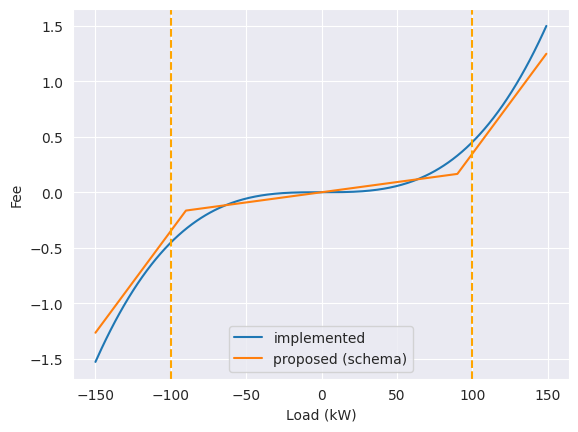

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

p = Path(".") / "plots" / "tariffs.png"
x1 = [x for x in np.arange(-150, 150, 1)]

def my_h(x):
    return 0.33 * ((x / 90)**3)
x2 = [my_h(x) for x in x1]

def proposed_h(x):
    if np.abs(x) < 90:
        return 0.5 * 0.33 * (x / 90)
    if np.abs(x) >= 90:
        y =  5 * 0.33 * (x / 90)
        if y < 0:
            y +=  5 * 0.33 - 0.5 * 0.33
        elif y > 0:
            y -=  5 * 0.33 - 0.5 * 0.33
        return y
x3 = [proposed_h(x) for x in x1]

data = {"Load (kW)": x1, "Fee": x2, "x3": x3}
df = pd.DataFrame(data)

ax = sns.lineplot(data=data, x="Load (kW)", y="Fee", label="implemented")
sns.lineplot(data=data, x="Load (kW)", y="x3", ax=ax, label="proposed (schema)")

plt.axvline(-100., color="orange", linestyle="--", label="Limit")
plt.axvline(100., color="orange", linestyle="--")

plt.savefig(p)
